In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np
import hdbscan
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
import gc
import numpy as np
import polars as pl
from dscribe.descriptors import SOAP
from rdkit import Chem
import numpy as np
import polars as pl
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
import polars as pl
from ase import Atoms
from dscribe.descriptors import SOAP
from rdkit import Chem
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split




from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from umap import UMAP
from dscribe.kernels import REMatchKernel

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, evaluate_hdbscan_grid, get_isomers

projection_method = "MDS"

In [3]:
qm9 = QM9Dataset(limit=5_000, descriptors=["transformer"])
df = qm9.load()

2026-05-29 12:43:39.527 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-29 12:43:39.927 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000, sampling on columns=['num_atoms', 'gap'].
2026-05-29 12:43:39.928 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-29 12:43:39.928 | INFO     | src.features:compute_selfies_transformer:242 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLa

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
2026-05-29 12:44:05.386 | INFO     | src.datasets:_add_requested_descriptors:213 - Added descriptor column(s): ['selfies_transformer']


In [3]:
import torch
from transformers import AutoTokenizer, AutoModel

def compute_selfies_transformer(selfies_series: pl.Series, 
                                    model_name: str = "HUBioDataLab/SELFormer", 
                                    batch_size: int = 32) -> pl.Series:
        """
        Computes molecular embeddings using the SELFormer encoder-only architecture.
        """

        device = 'mps'
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True, output_hidden_states=True).to(device)
        model.eval()
        clean_selfies = [s.replace("][", "] [") if s else "[nop]" for s in selfies_series.to_list()]
        embeddings = []
        
        with torch.no_grad():
            for i in range(0, len(clean_selfies), batch_size):
                batch = clean_selfies[i : i + batch_size]
                
                inputs = tokenizer(
                    batch, 
                    padding=True, 
                    truncation=True, 
                    max_length=256,
                    return_tensors="pt"
                ).to(device)
                
                outputs = model(**inputs)
                
                #hidden_states = outputs.last_hidden_state
                hidden_states = outputs.hidden_states[6]
                
                mask = inputs["attention_mask"].unsqueeze(-1).expand(hidden_states.size()).float()
                sum_embeddings = torch.sum(hidden_states * mask, dim=1)
                sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
                mean_pooled = sum_embeddings / sum_mask
                
                embeddings.extend(mean_pooled.cpu().tolist())

        return pl.Series("selfies_transformer", embeddings)

# Hypothesis 1
- it can manage shuffled selfies strings

In [5]:
from time import time
from tqdm import tqdm
import random
import selfies as sf

def generate_augmentations(smiles_str, num_variants=20, timeout=1):
    """Generates unique randomized SMILES for a single input molecule."""
    mol = Chem.MolFromSmiles(smiles_str)
    mol = Chem.RemoveHs(mol)
    if not mol:
        return []
    
    unique_variants = {Chem.MolToSmiles(mol, canonical=True)}
    start_time = time()
    
    while len(unique_variants) < num_variants:
        if (time() - start_time) > timeout:
            break
        
        # doRandom=True creates a new valid path through the molecular graph
        v = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        unique_variants.add(v)
        
    return list(unique_variants)

# 1. Filter and Sample
long_smiles = [s for s in df['canonical_smiles'] if len(s) > 50]
sample_pool = random.sample(long_smiles, min(len(long_smiles), 50))
chosen_smiles = []

# 2. Process
all_combinations = []
selfies_variants = []
i = 0
for s in tqdm(sample_pool, desc="Augmenting Molecules"):
    variants = generate_augmentations(s, num_variants=20)
    
    if len(variants) < 20:
        tqdm.write(f"Note: Only generated {len(variants)} variants for a molecule (timeout).")
        continue
    
    chosen_smiles.extend([s]*20)
    all_combinations.append(variants)
    
    i += 1
    if i >= 20:
        break
    
all_combinations = np.array(all_combinations).flatten()
selfies_variants = [sf.encoder(s) for s in all_combinations]

Augmenting Molecules:   0%|          | 0/13 [00:00<?, ?it/s]

Augmenting Molecules: 100%|██████████| 13/13 [00:00<00:00, 735.96it/s]


In [6]:
variants

['C1[C@H]2[C@@H]3[C@H]4O[C@@H]([NH2+][C@H]13)[C@@H]24',
 '[C@H]12O[C@@H]3[C@@H]4[C@@H](C[C@@H]4[C@H]23)[NH2+]1',
 '[C@@H]12O[C@H]3[C@@H]1[C@H]1C[C@@H]([NH2+]2)[C@@H]31',
 '[C@H]12[C@H]3[C@H]4[C@@H]2C[C@H]4[NH2+][C@@H]1O3',
 'O1[C@H]2[C@@H]3[C@@H]4[C@H]2[C@H]([NH2+][C@@H]31)C4',
 '[NH2+]1[C@H]2[C@@H]3[C@H](O2)[C@@H]2[C@H]1C[C@@H]23',
 '[C@@H]12O[C@@H]3[C@H]2[C@@H]2[C@H]1[C@H]([NH2+]3)C2',
 '[C@@H]12[C@@H]3[C@@H]([C@@H]4[C@@H](O[C@H]34)[NH2+]1)C2',
 '[C@H]12[C@H]3[C@H]4C[C@H]([C@H]4[C@H]3O1)[NH2+]2',
 '[C@H]12C[C@@H]3[C@H]1[C@H]1O[C@@H]([NH2+]3)[C@H]12',
 '[C@@H]12O[C@H]3[NH2+][C@H]4[C@@H]1[C@H](C4)[C@H]32',
 '[C@@H]12C[C@H]3[C@@H]1[C@@H]1[C@H]3[C@@H](O1)[NH2+]2',
 '[C@H]12[C@H]3[C@H]([NH2+][C@@H]4C[C@H]3[C@H]14)O2',
 '[C@@H]12C[C@H]3[C@@H]1[C@@H]1[C@H]3[C@H]([NH2+]2)O1',
 '[C@@H]12[C@@H]3[C@@H]4[C@H]2C[C@H]1[NH2+][C@@H]4O3',
 'C1[C@@H]2[C@@H]3[C@H]4O[C@@H]3[C@@H]2[C@@H]1[NH2+]4',
 '[NH2+]1[C@@H]2O[C@H]3[C@@H]2[C@@H]2[C@H]3[C@H]1C2',
 '[C@H]12C[C@@H]3[C@@H]4[C@@H](O[C@@H]4[C@@H]32)[NH2+]

Augmenting Molecules:  38%|███▊      | 19/50 [00:00<00:00, 739.19it/s]


Computing SELFormer embeddings for shuffled strings...


INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.

Computing SELFormer embeddings for canonical strings...


INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested

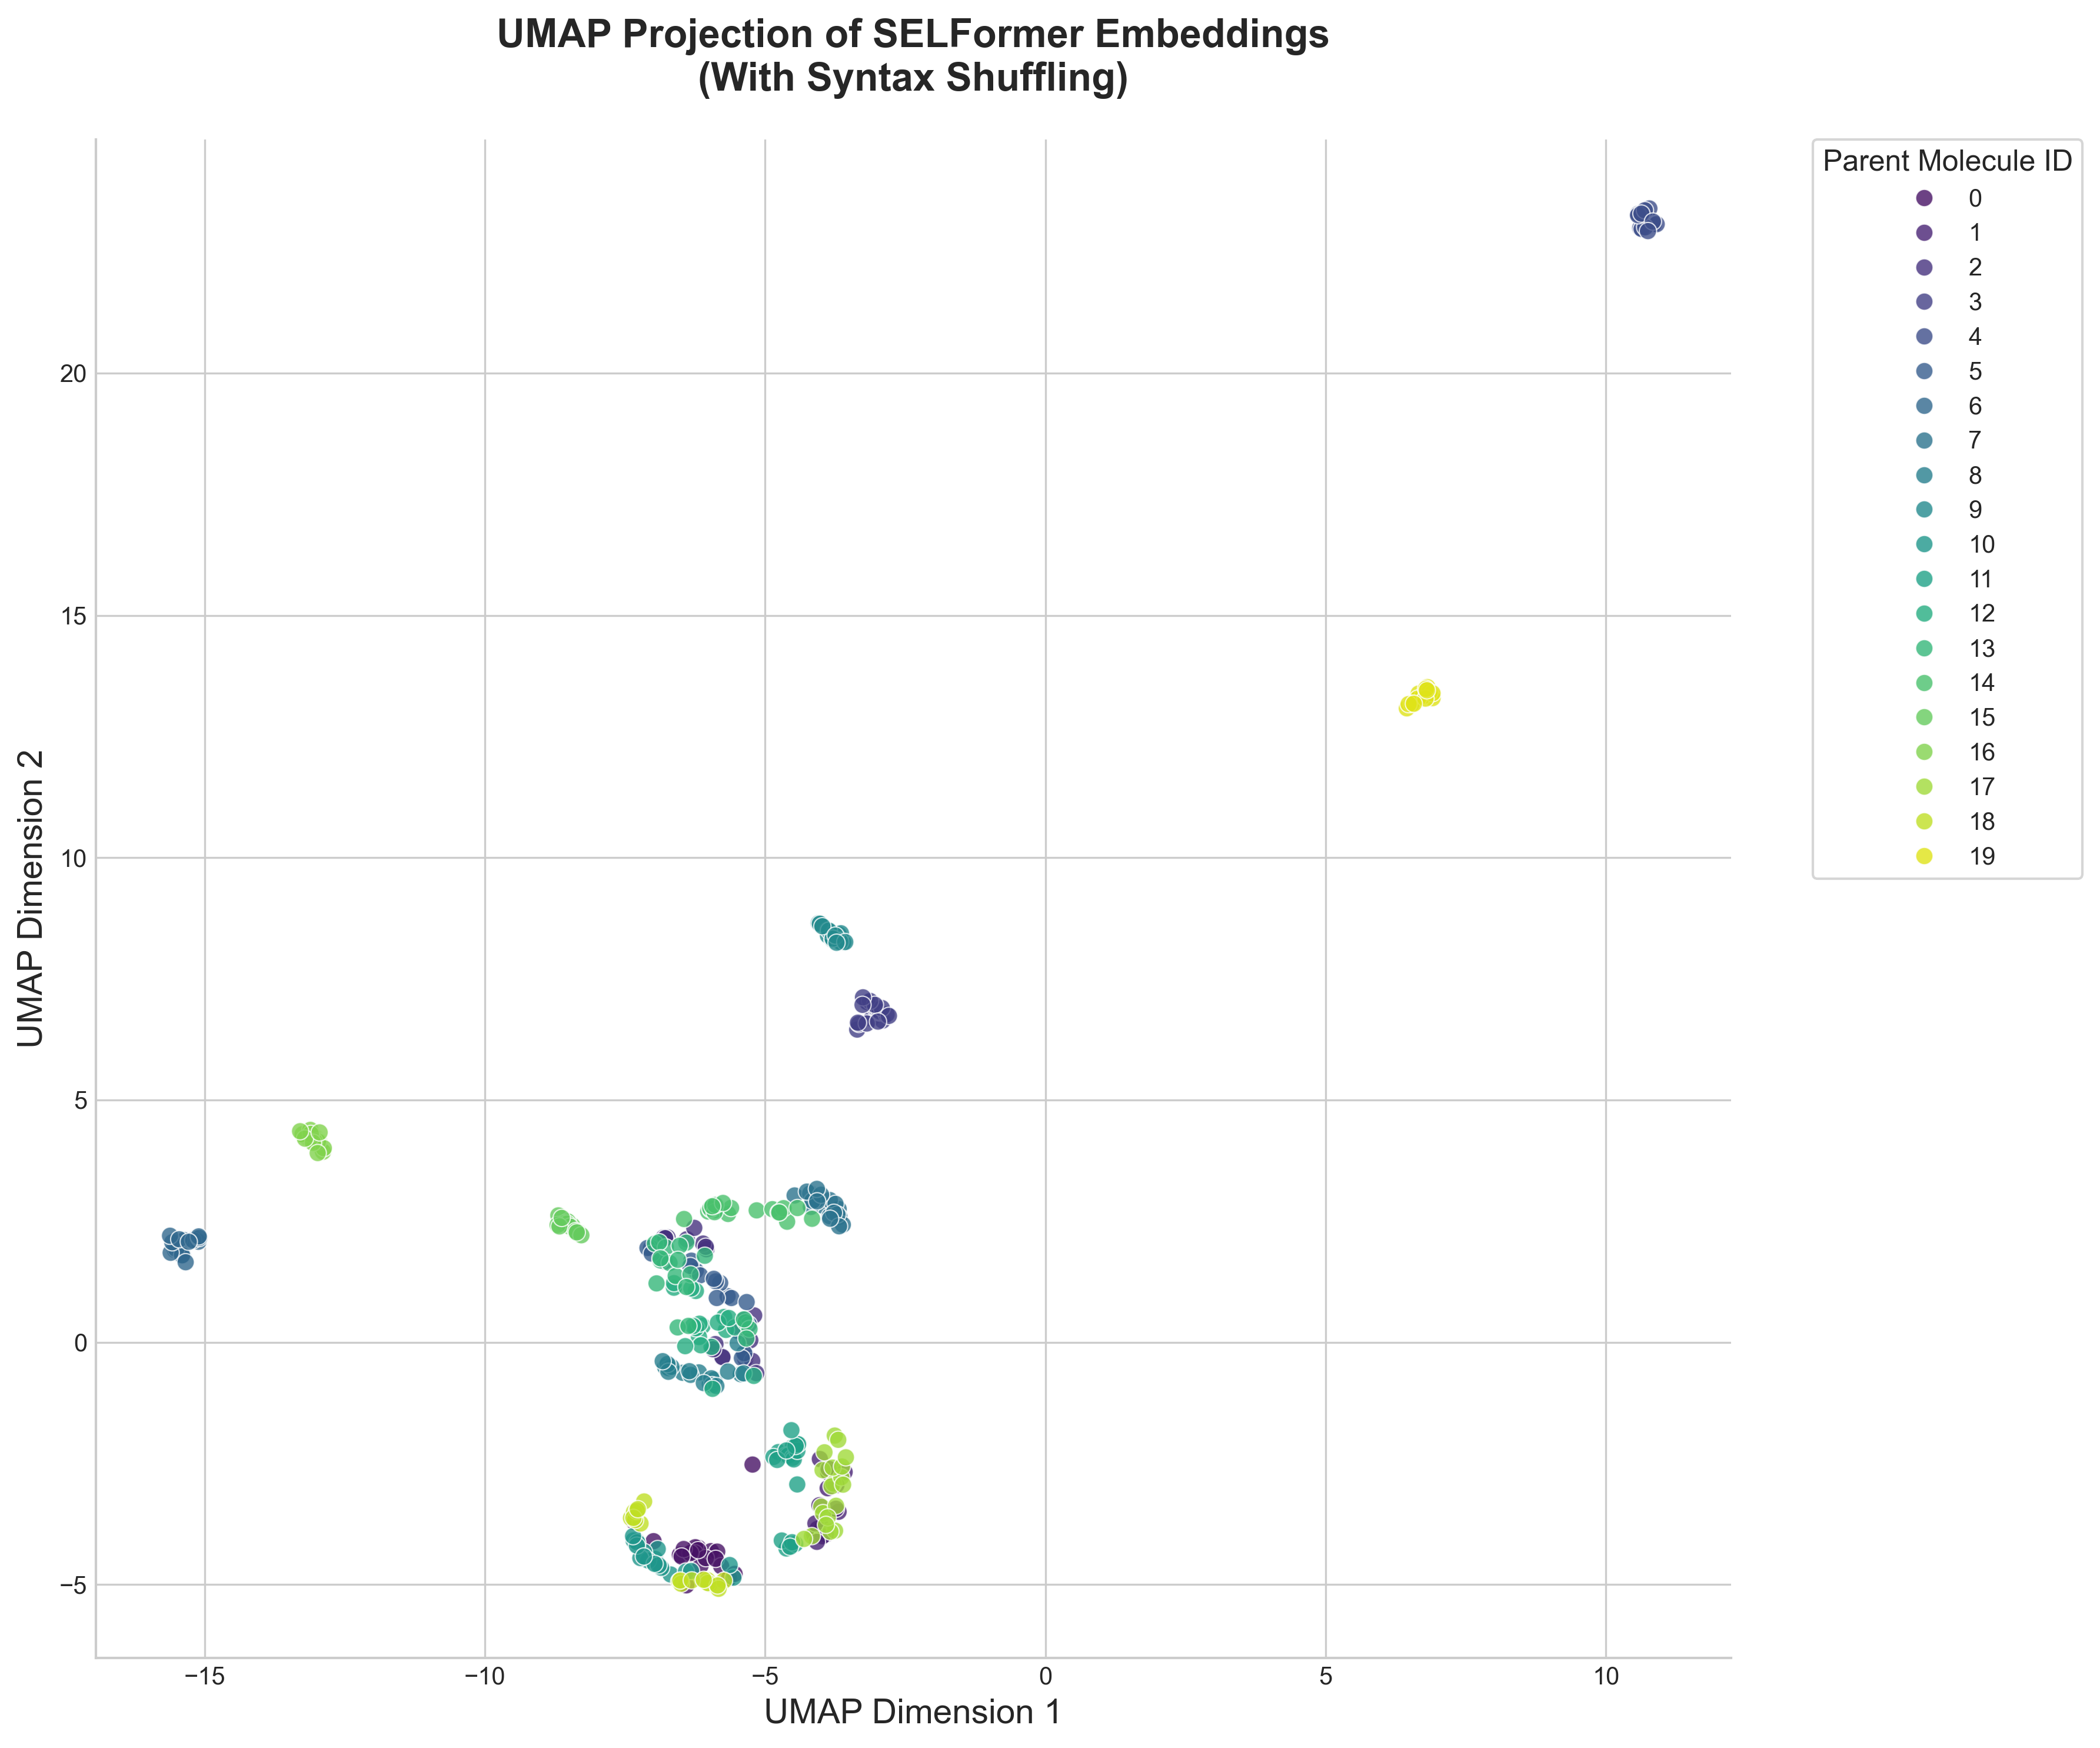

Saved: selformer_umap_shuffled.png


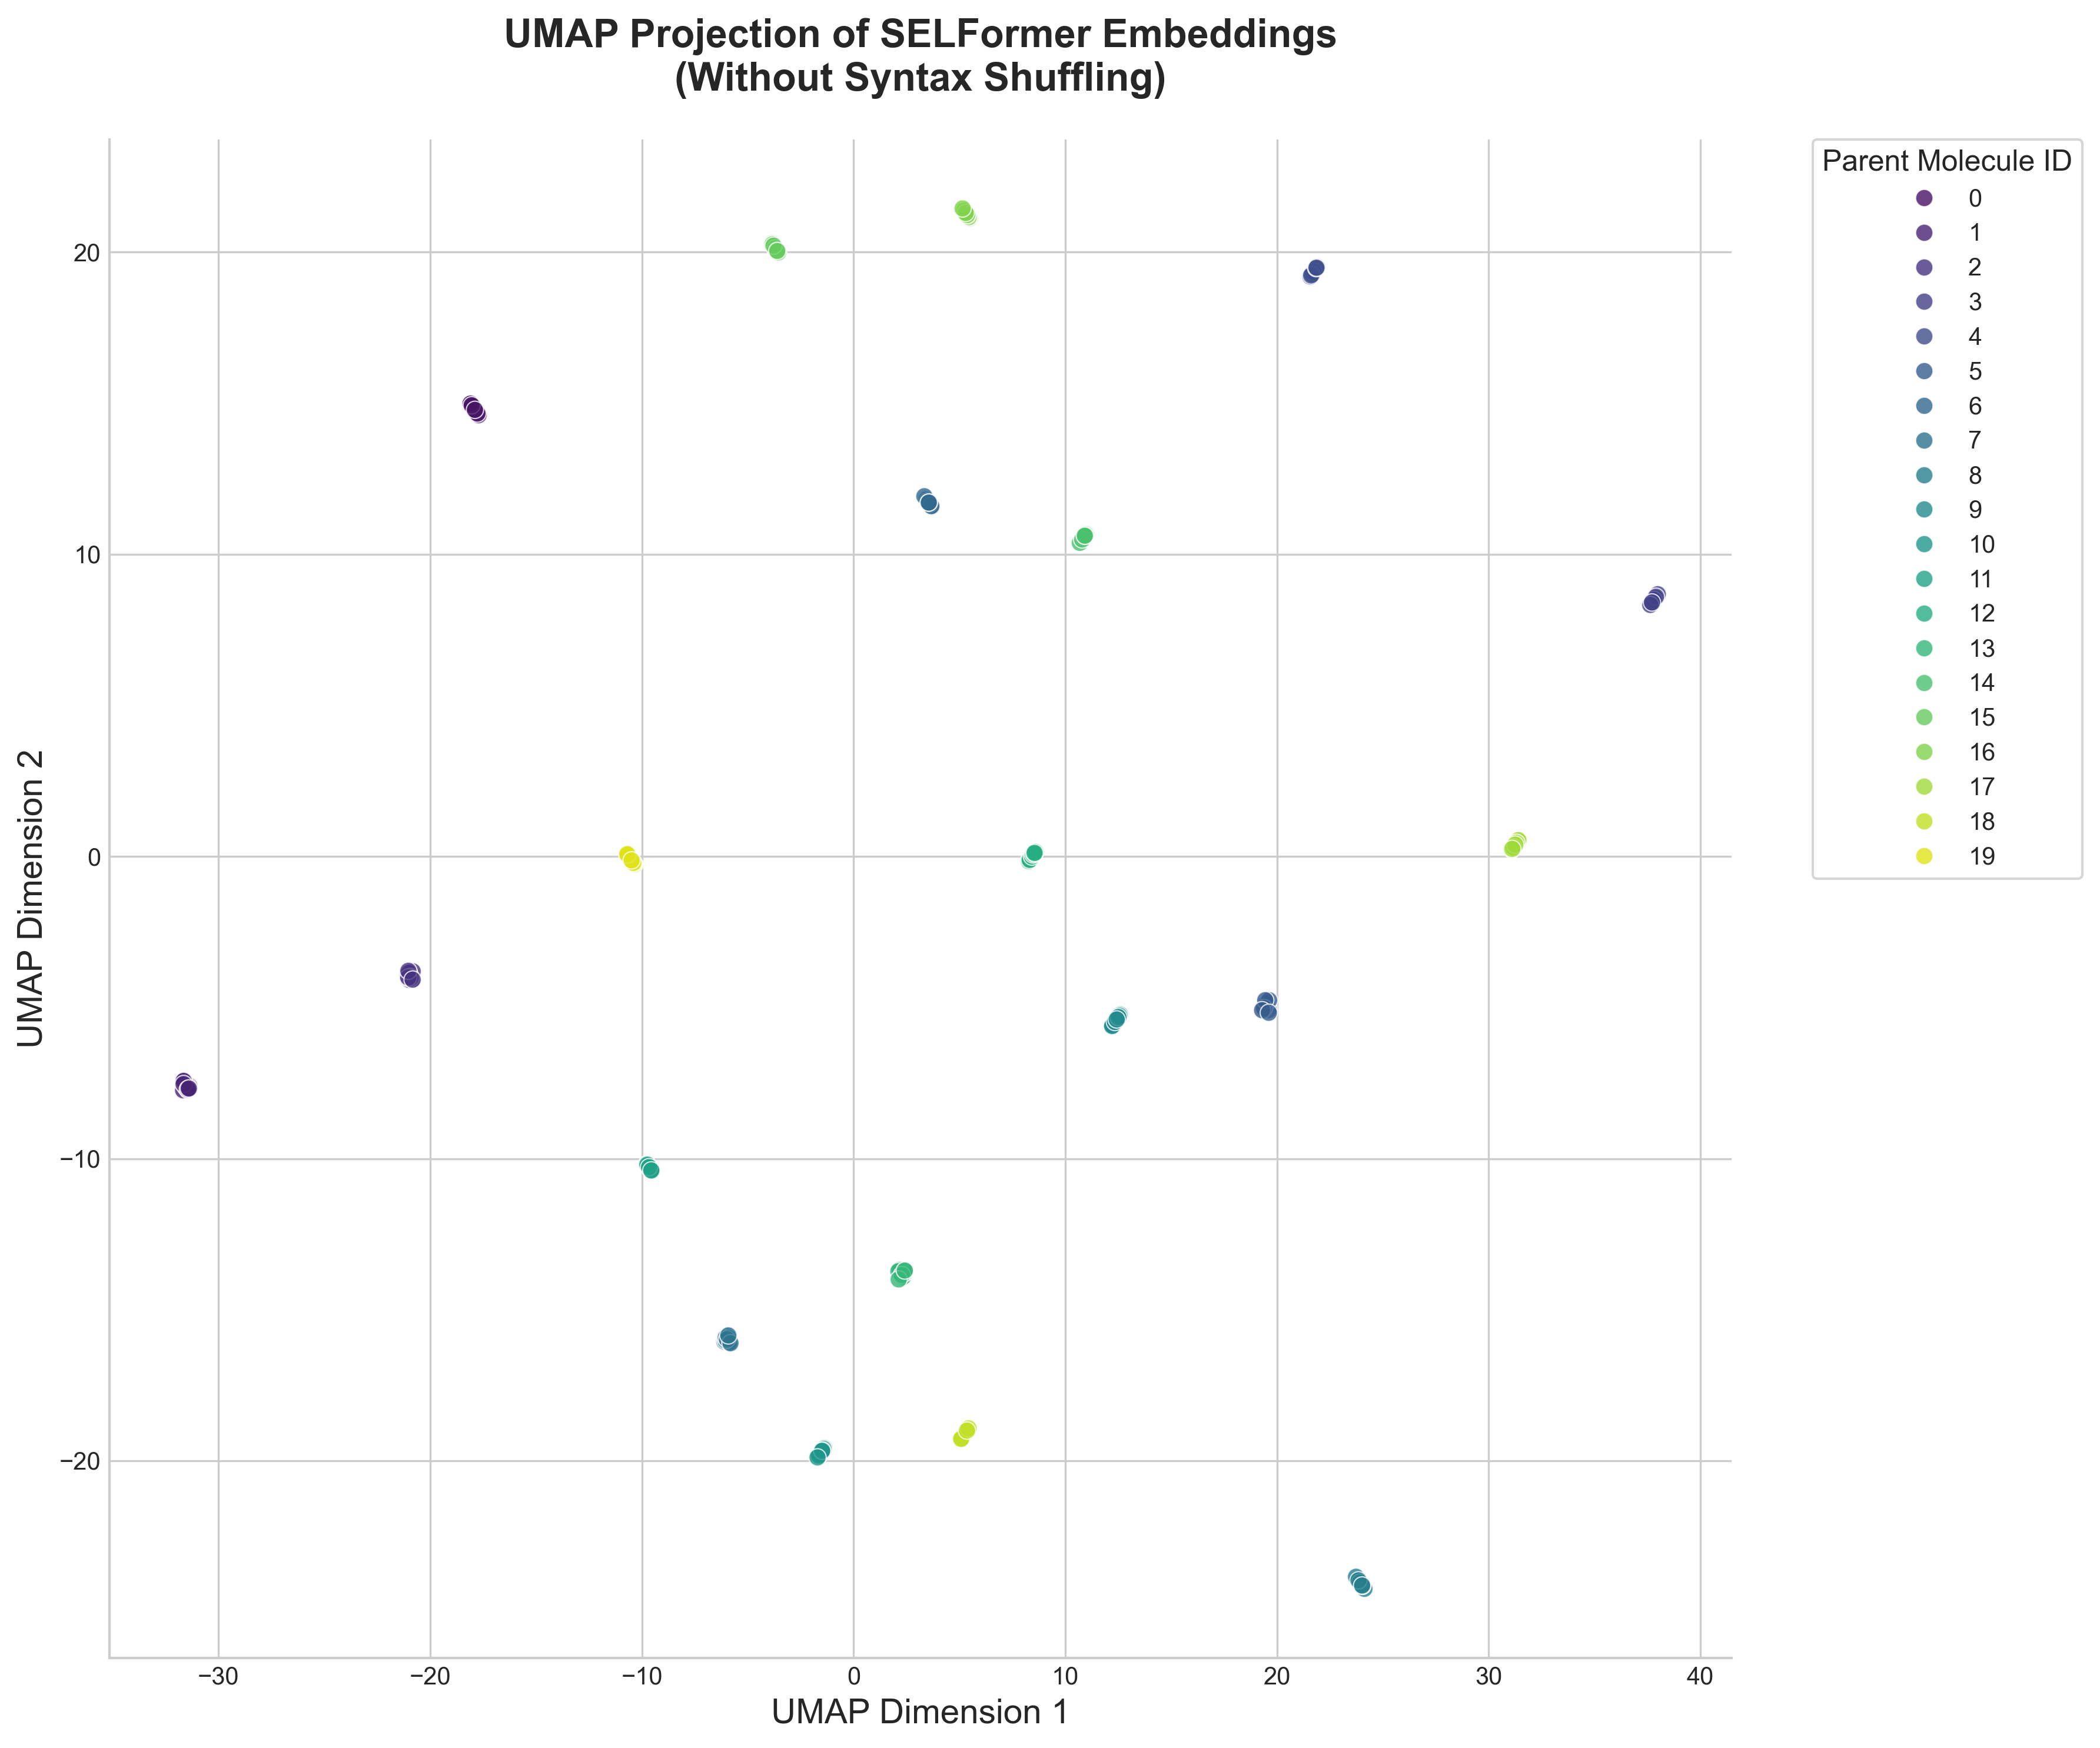

Saved: selformer_umap_canonical.png


In [7]:
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from umap import UMAP
from time import time
from tqdm import tqdm
import random
import selfies as sf

def generate_augmentations(smiles_str, num_variants=20, timeout=1):
    """Generates unique randomized SMILES for a single input molecule."""
    mol = Chem.MolFromSmiles(smiles_str)
    mol = Chem.RemoveHs(mol)
    if not mol:
        return []
    
    unique_variants = {Chem.MolToSmiles(mol, canonical=True)}
    start_time = time()
    
    while len(unique_variants) < num_variants:
        if (time() - start_time) > timeout:
            break
        
        v = Chem.MolToSmiles(mol, doRandom=True, canonical=False)
        unique_variants.add(v)
        
    return list(unique_variants)

# --- 1. Filter and Sample ---
long_smiles = [s for s in df['smiles'] if len(s) > 50]
sample_pool = random.sample(long_smiles, min(len(long_smiles), 50))

all_combinations_shuffled = []
all_combinations_canonical = []
i = 0

for s in tqdm(sample_pool, desc="Augmenting Molecules"):
    variants = generate_augmentations(s, num_variants=20)
    
    if len(variants) < 20:
        tqdm.write(f"Note: Only generated {len(variants)} variants for a molecule (timeout).")
        continue
    
    # Shuffled variants
    all_combinations_shuffled.append(variants)
    
    # Canonical/unshuffled control: repeat the canonical string 20 times
    mol = Chem.MolFromSmiles(s)
    canonical_smiles = Chem.MolToSmiles(mol, canonical=True)
    all_combinations_canonical.append([canonical_smiles] * 20)
    
    i += 1
    if i >= 20:
        break
    
all_combinations_shuffled = np.array(all_combinations_shuffled).flatten()
all_combinations_canonical = np.array(all_combinations_canonical).flatten()

# Convert strings to SELFIES
selfies_variants_shuffled = [sf.encoder(s) for s in all_combinations_shuffled]
selfies_variants_canonical = [sf.encoder(s) for s in all_combinations_canonical]

# --- 2. Compute SELFormer Embeddings ---
# Shared tracking labels for both scenarios
parent_labels = np.repeat(np.arange(20), 20) 

print("Computing SELFormer embeddings for shuffled strings...")
emb_series_shuffled = compute_selfies_transformer(pl.Series("selfies", selfies_variants_shuffled), model_name="HUBioDataLab/SELFormer", batch_size=32)
X_emb_shuffled = np.array(emb_series_shuffled.to_list())

print("Computing SELFormer embeddings for canonical strings...")
emb_series_canonical = compute_selfies_transformer(pl.Series("selfies", selfies_variants_canonical), model_name="HUBioDataLab/SELFormer", batch_size=32)
X_emb_canonical = np.array(emb_series_canonical.to_list())

# --- 3. Project onto 2D Space using UMAP ---
reducer_shuffled = UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
X_umap_shuffled = reducer_shuffled.fit_transform(X_emb_shuffled)

reducer_canonical = UMAP(n_neighbors=15, min_dist=0.1, metric="euclidean", random_state=42)
X_umap_canonical = reducer_canonical.fit_transform(X_emb_canonical)

# --- 4. Plotting Function ---
def plot_umap_panel(X_umap, labels, title, filename):
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 10), dpi=300)
    
    n_colors = len(np.unique(labels))
    palette = sns.color_palette("viridis", n_colors=n_colors)
    
    sns.scatterplot(
        x=X_umap[:, 0], 
        y=X_umap[:, 1], 
        hue=labels, 
        palette=palette,
        s=50,          
        alpha=0.8,     
        edgecolor='w', 
        linewidth=0.5,
        ax=ax
    )
    
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel("UMAP Dimension 1", fontsize=14, fontweight='medium')
    ax.set_ylabel("UMAP Dimension 2", fontsize=14, fontweight='medium')
    
    ax.legend(
        title="Parent Molecule ID",
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        borderaxespad=0.,
        frameon=True,
        title_fontsize=12,
        fontsize=10,
        ncol=1
    )
    
    sns.despine(fig)
    plt.tight_layout()
    #plt.savefig(filename, bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f"Saved: {filename}")

# --- 5. Generate both plots ---
plot_umap_panel(
    X_umap=X_umap_shuffled, 
    labels=parent_labels, 
    title="UMAP Projection of SELFormer Embeddings\n(With Syntax Shuffling)", 
    filename="selformer_umap_shuffled.png"
)

plot_umap_panel(
    X_umap=X_umap_canonical, 
    labels=parent_labels, 
    title="UMAP Projection of SELFormer Embeddings\n(Without Syntax Shuffling)", 
    filename="selformer_umap_canonical.png"
)

In [8]:
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut
from scipy.spatial.distance import pdist, squareform

def calculate_latent_metrics(X_embeddings, labels):
    """
    Calculates quantitative metrics directly on high-dimensional embeddings.
    """
    # 1. Global Silhouette Score
    sil_score = silhouette_score(X_embeddings, labels, metric="euclidean")
    
    # 2. Compute full pairwise distance matrix for intra/inter calculations
    dist_matrix = squareform(pdist(X_embeddings, metric="euclidean"))
    
    intra_distances = []
    inter_distances = []
    
    unique_labels = np.unique(labels)
    
    for label in unique_labels:
        # Mask for current parent molecule variants
        intra_mask = (labels == label)
        
        # Intra-molecule distances (exclude self-distance diagonal)
        molecule_dists = dist_matrix[intra_mask][:, intra_mask]
        if molecule_dists.size > 1:
            # Grab upper triangle to avoid duplication and 0.0 diagonal
            triu_idx = np.triu_indices_from(molecule_dists, k=1)
            intra_distances.extend(molecule_dists[triu_idx])
            
        # Inter-molecule distances
        inter_mask = (labels != label)
        inter_dists = dist_matrix[intra_mask][:, inter_mask]
        inter_distances.extend(inter_dists.flatten())
        
    mean_intra = np.mean(intra_distances)
    std_intra = np.std(intra_distances)
    mean_inter = np.mean(inter_distances)
    std_inter = np.std(inter_distances)
    
    # Avoid DivisionByZero if canonical collapse means intra distance is 0
    intra_inter_ratio = mean_intra / mean_inter if mean_inter > 0 else 0.0

    # 3. Leave-One-Out 1-NN Accuracy
    # Predict parent class using the closest single neighbor in the latent space
    loo = LeaveOneOut()
    correct_predictions = 0
    
    # Pre-calculated 1-NN over LOO split
    knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
    
    for train_idx, test_idx in loo.split(X_embeddings):
        X_train, X_test = X_embeddings[train_idx], X_embeddings[test_idx]
        y_train, y_test = labels[train_idx], labels[test_idx]
        
        knn.fit(X_train, y_train)
        pred = knn.predict(X_test)
        if pred[0] == y_test[0]:
            correct_predictions += 1
            
    knn_accuracy = (correct_predictions / len(labels)) * 100

    return {
        "silhouette": sil_score,
        "mean_intra": mean_intra,
        "std_intra": std_intra,
        "mean_inter": mean_inter,
        "std_inter": std_inter,
        "ratio": intra_inter_ratio,
        "1nn_accuracy": knn_accuracy
    }

# --- Compute Stats for Shuffled Experiment ---
print("\n--- Evaluation: With Syntax Shuffling ---")
shuffled_metrics = calculate_latent_metrics(X_emb_shuffled, parent_labels)
print(f"Silhouette Score:       {shuffled_metrics['silhouette']:.4f}")
print(f"Mean Intra-Dist:        {shuffled_metrics['mean_intra']:.4f} ± {shuffled_metrics['std_intra']:.4f}")
print(f"Mean Inter-Dist:        {shuffled_metrics['mean_inter']:.4f} ± {shuffled_metrics['std_inter']:.4f}")
print(f"Intra/Inter Ratio:      {shuffled_metrics['ratio']:.4f}")
print(f"1-NN LOO Accuracy:      {shuffled_metrics['1nn_accuracy']:.2f}%")

# --- Compute Stats for Canonical Control Experiment ---
print("\n--- Evaluation: Without Shuffling (Canonical Control) ---")
canonical_metrics = calculate_latent_metrics(X_emb_canonical, parent_labels)
print(f"Silhouette Score:       {canonical_metrics['silhouette']:.4f}")
print(f"Mean Intra-Dist:        {canonical_metrics['mean_intra']:.4f} ± {canonical_metrics['std_intra']:.4f}")
print(f"Mean Inter-Dist:        {canonical_metrics['mean_inter']:.4f} ± {canonical_metrics['std_inter']:.4f}")
print(f"Intra/Inter Ratio:      {canonical_metrics['ratio']:.4f}")
print(f"1-NN LOO Accuracy:      {canonical_metrics['1nn_accuracy']:.2f}%")


--- Evaluation: With Syntax Shuffling ---
Silhouette Score:       0.1649
Mean Intra-Dist:        2.8206 ± 0.7580
Mean Inter-Dist:        4.7143 ± 1.2697
Intra/Inter Ratio:      0.5983
1-NN LOO Accuracy:      94.75%

--- Evaluation: Without Shuffling (Canonical Control) ---
Silhouette Score:       1.0000
Mean Intra-Dist:        0.0000 ± 0.0000
Mean Inter-Dist:        5.0165 ± 1.4093
Intra/Inter Ratio:      0.0000
1-NN LOO Accuracy:      100.00%


=== Embedding Space Distance Metrics ===
Intra-Molecule Distance (Same Parent):  Mean = 2.8206 ± 0.7580
Inter-Molecule Distance (Diff Parents): Mean = 4.7143 ± 1.2697
Intra/Inter Distance Ratio:             0.5983


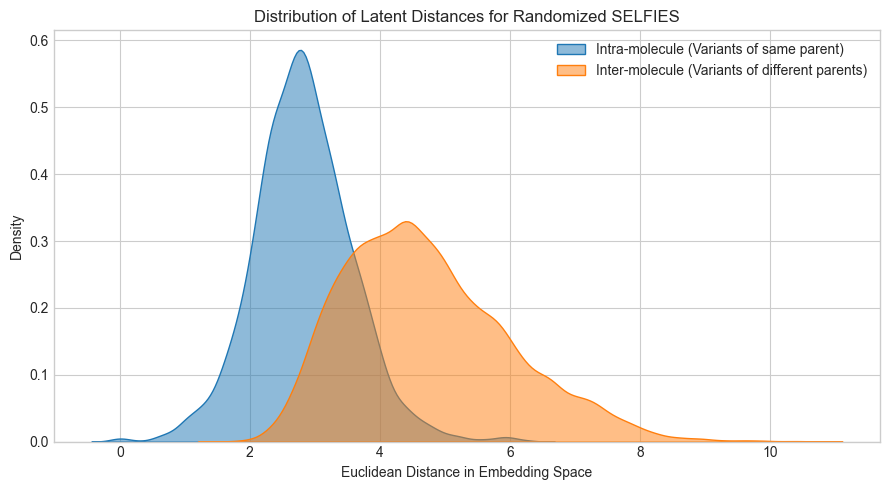

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

# 1. Compute the full pairwise Euclidean distance matrix
# Shape will be (400, 400) since you have 20 parents * 20 variants
dist_matrix = euclidean_distances(X_emb_shuffled)

# 2. Extract intra and inter metrics
intra_distances = []
inter_distances = []

# Labels tracking which parent index (0 to 19) each row belongs to
parent_labels = np.repeat(np.arange(20), 20)

for i in range(len(parent_labels)):
    for j in range(i + 1, len(parent_labels)):  # Symmetric matrix, skip duplicates/self
        dist = dist_matrix[i, j]
        if parent_labels[i] == parent_labels[j]:
            intra_distances.append(dist)
        else:
            inter_distances.append(dist)

# Convert to arrays for statistical summaries
intra_distances = np.array(intra_distances)
inter_distances = np.array(inter_distances)

# 3. Print Statistical Summary
print("=== Embedding Space Distance Metrics ===")
print(f"Intra-Molecule Distance (Same Parent):  Mean = {intra_distances.mean():.4f} ± {intra_distances.std():.4f}")
print(f"Inter-Molecule Distance (Diff Parents): Mean = {inter_distances.mean():.4f} ± {inter_distances.std():.4f}")

# Calculate Ratio (Lower is better: indicates tight clusters far apart)
ratio = intra_distances.mean() / inter_distances.mean()
print(f"Intra/Inter Distance Ratio:             {ratio:.4f}")

# 4. Plot the Distribution Overlap
plt.figure(figsize=(9, 5))
sns.kdeplot(intra_distances, label="Intra-molecule (Variants of same parent)", fill=True, alpha=0.5)
sns.kdeplot(inter_distances, label="Inter-molecule (Variants of different parents)", fill=True, alpha=0.5)
plt.xlabel("Euclidean Distance in Embedding Space")
plt.ylabel("Density")
plt.title("Distribution of Latent Distances for Randomized SELFIES")
plt.legend()
plt.tight_layout()
plt.show()

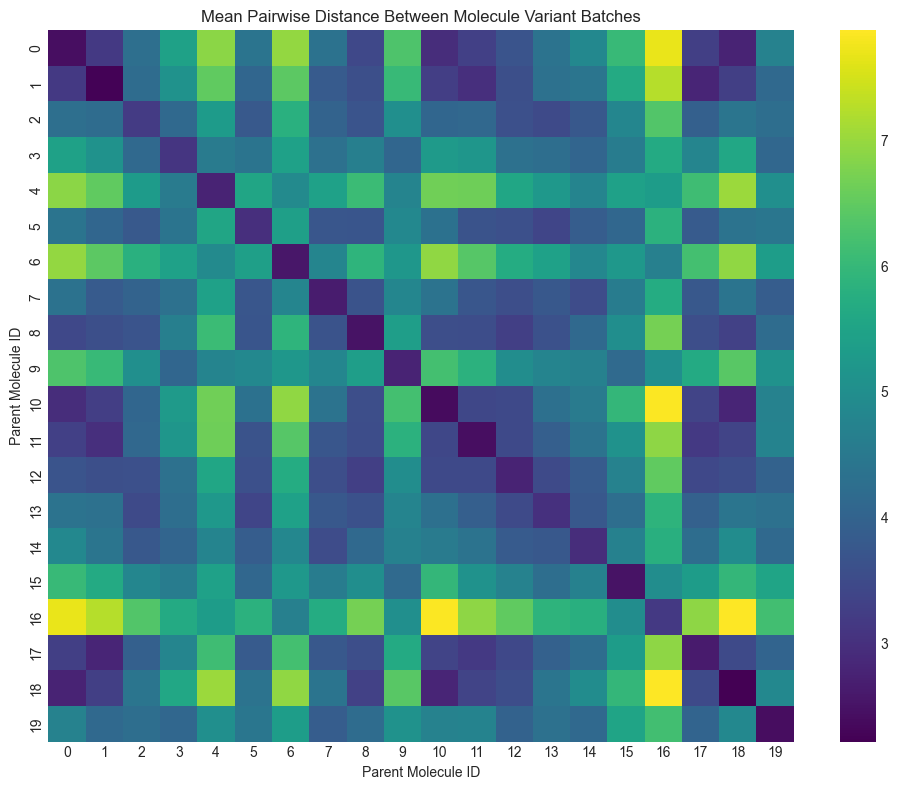

In [10]:
# Compute average distance between the 20 clusters
macro_dist_matrix = np.zeros((20, 20))

for i in range(20):
    for j in range(20):
        # Slice out the 20x20 block representing distances between parent i and parent j
        block = dist_matrix[i*20 : (i+1)*20, j*20 : (j+1)*20]
        macro_dist_matrix[i, j] = block.mean()

# Plotting the macro cluster distance heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(macro_dist_matrix, cmap="viridis", xticklabels=True, yticklabels=True)
plt.title("Mean Pairwise Distance Between Molecule Variant Batches")
plt.xlabel("Parent Molecule ID")
plt.ylabel("Parent Molecule ID")
plt.tight_layout()
plt.show()

# Hypo 2

In [4]:
qm9_all = QM9Dataset(limit=None)
df_all = qm9_all.load()
df_all = df_all.filter((~pl.col("functional_groups").str.contains(',')) & (pl.col("functional_groups") != ""))

2026-05-29 12:49:07.461 | INFO     | src.datasets:_load_full_qm9_df:817 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-29 12:49:07.953 | INFO     | src.datasets:_sample_qm9_df:1000 - QM9 sampling complete: strategy=stratified, requested_limit=None, returned_rows=124232, sampling on columns=['num_atoms', 'gap'].


In [5]:
df_all['functional_groups'].value_counts(sort=True)

functional_groups,count
str,u32
"""ether""",27432
"""alcohol""",16542
"""ketone""",5758
"""amide""",5590
"""amine""",4321
"""phenol""",1974
"""halogen""",863
"""nitro""",89
"""carboxylic_acid""",62


In [6]:
df_cleaned = (
    df_all
    .filter(
        pl.col("functional_groups").is_in(["ether", "alcohol", "amine"]),
        pl.col("num_rings") == 0,
        pl.col("num_heteroatoms") <= 2
    )
)

# 2. Optimize strictly for raw_token_count (The critical OHE confounder)
best_config = (
    df_cleaned
    .group_by("raw_token_count", "functional_groups")
    .len()
    # Find the bottleneck group size for each token_count
    .group_by("raw_token_count")
    .agg(
        pl.col("functional_groups").n_unique().alias("unique_group_count"),
        pl.col("len").min().alias("min_samples_per_group")
    )
    # Enforce that all 3 functional groups must exist at this token length
    .filter(pl.col("unique_group_count") == 3)
    # Maximize our balanced sample pool
    .sort("min_samples_per_group", descending=True)
    .head(1)
)

token_counts_df = (
    df_cleaned
    .group_by("raw_token_count", "functional_groups")
    .len()
    .group_by("raw_token_count")
    .agg(
        pl.col("functional_groups").n_unique().alias("unique_group_count"),
        pl.col("len").min().alias("min_samples_per_group")
    )
    .filter(pl.col("unique_group_count") == 3)
    .sort("min_samples_per_group", descending=True)
)

best_config = token_counts_df.head(1)
optimal_token_count = best_config["raw_token_count"].item(0)
max_equal_n = best_config["min_samples_per_group"].item(0)

In [7]:
df_sample = (
    df_cleaned
    .filter(pl.col("raw_token_count") == optimal_token_count)
    .group_by("functional_groups")
    .map_groups(lambda group: group.sample(n=30, seed=42, with_replacement=False))
    .sort("functional_groups")
)

In [8]:
def compute_semantic_embeddings(selfies_series: pl.Series, layer_idx: int = 6) -> np.ndarray:
    device = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = "HUBioDataLab/SELFormer"
    
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    model = AutoModel.from_pretrained(model_name, trust_remote_code=True, output_hidden_states=True).to(device)
    model.eval()
    
    clean_selfies = [s.replace("][", "] [") if s else "[nop]" for s in selfies_series.to_list()]
    embeddings = []
    
    with torch.no_grad():
        for s in clean_selfies:
            inputs = tokenizer(s, return_tensors="pt").to(device)
            outputs = model(**inputs)
            
            # Extract the robust intermediate hidden states
            hidden_states = outputs.hidden_states[layer_idx]
            
            # Mean pool across sequence length
            mean_pooled = torch.mean(hidden_states, dim=1)
            embeddings.append(mean_pooled.squeeze().cpu().numpy())
            
    return np.array(embeddings)

print("Extracting chemical semantic features from SELFormer Layer 6...")
X_embeddings = compute_semantic_embeddings(df_sample["selfies"], layer_idx=6)
labels = np.array(df_sample["functional_groups"].to_list())

Extracting chemical semantic features from SELFormer Layer 6...


INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
INFO: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/HUBioDataLab/SELFormer/177d98b158e999a6cb7fc9743dbfe1e8a17c57e5/tokenizer_config.json "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/main "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/discussions?p=0 "HTTP/1.1 200 OK"
INFO: HTTP Request: GET https://huggingface.co/api/models/HUBioDataLab/SELFormer/commits/refs%2Fpr%2F1 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors.index.json "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/HUBioDataLab/SELFormer/resolve/refs%2Fpr%2F1/model.safetensors "HTTP/1.1 302 Found"


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Saved high-res plot to selformer_functional_clustering.png


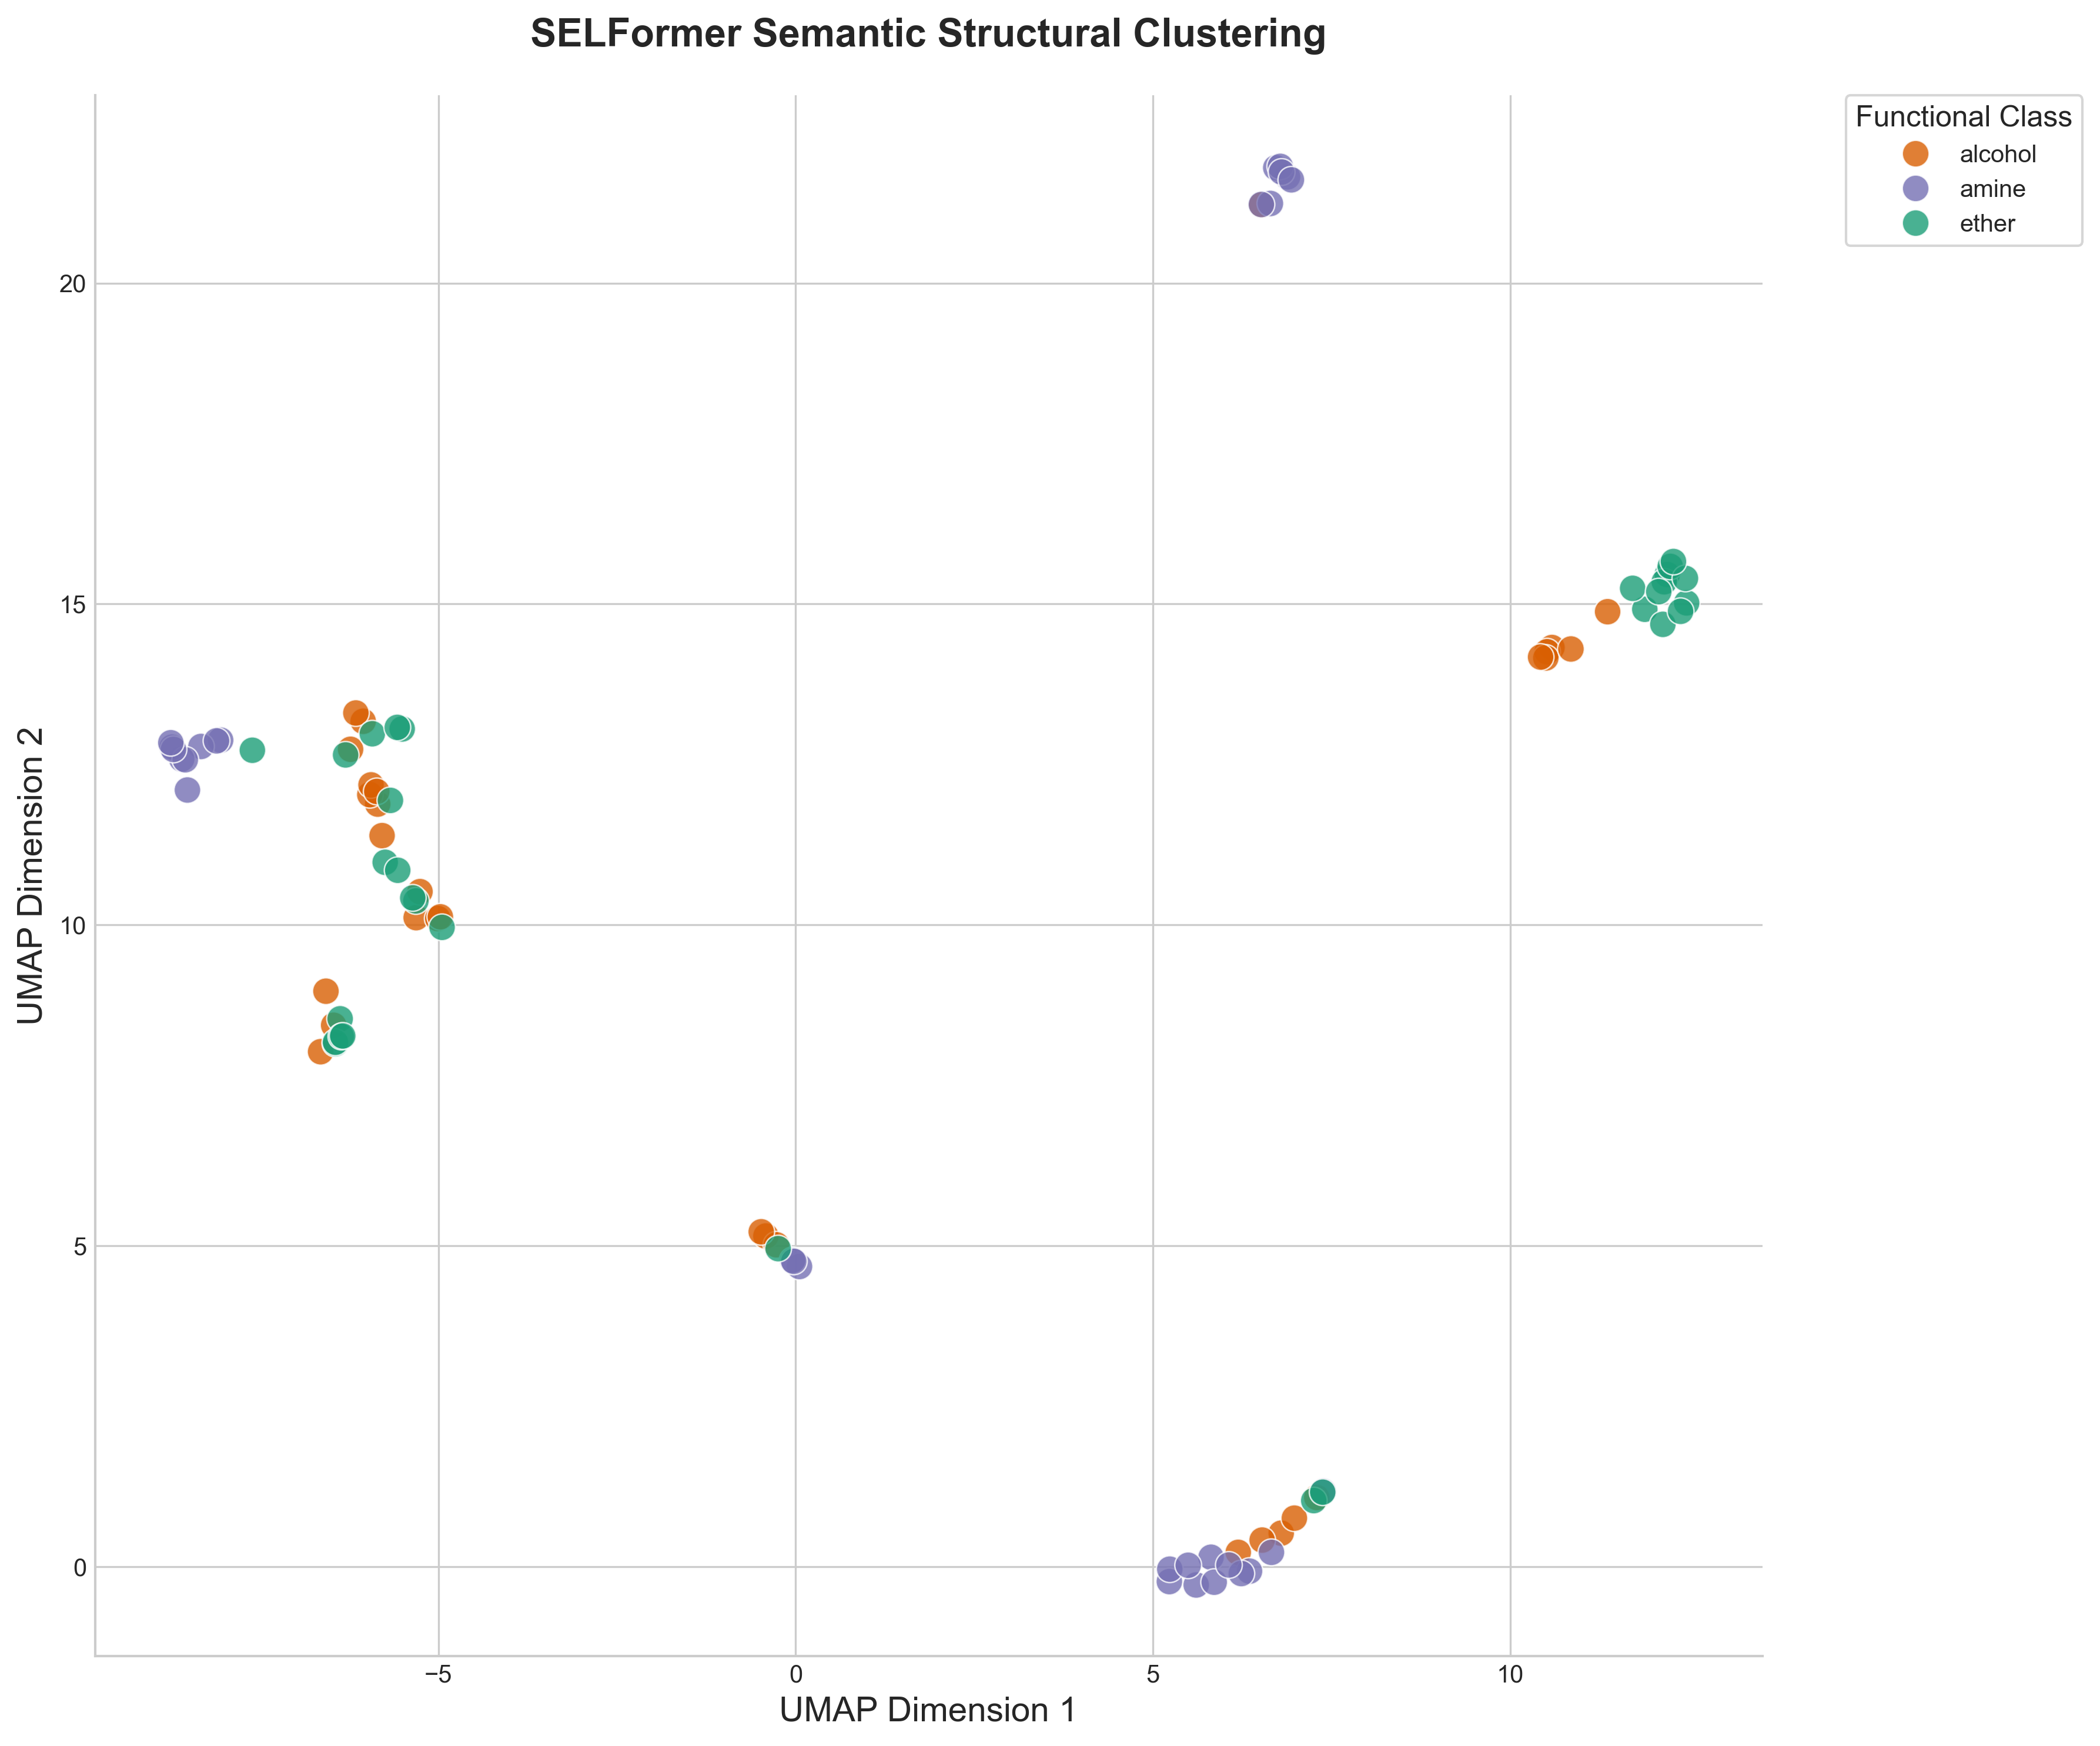

In [9]:
from sklearn.metrics import pairwise_distances
from umap import UMAP
dist_matrix = pairwise_distances(np.array(X_embeddings), metric="euclidean")
n = 5
reducer = UMAP(n_neighbors=n, metric="precomputed", random_state=42)
X_umap = reducer.fit_transform(dist_matrix)

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 10), dpi=300)

custom_colors = ['#d95f02', '#7570b3', '#1b9e77']
palette = sns.color_palette(custom_colors)

sns.scatterplot(
    x=X_umap[:, 0], 
    y=X_umap[:, 1], 
    hue=labels, 
    palette=palette,
    s=120,         
    alpha=0.8,     
    edgecolor='w', 
    linewidth=0.6,
    ax=ax
)

ax.set_title("SELFormer Semantic Structural Clustering", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("UMAP Dimension 1", fontsize=14, fontweight='medium')
ax.set_ylabel("UMAP Dimension 2", fontsize=14, fontweight='medium')

ax.legend(
    title="Functional Class", 
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0.,
    frameon=True,
    title_fontsize=12,
    fontsize=10
)

sns.despine(fig)
plt.tight_layout()

print("Saved high-res plot to selformer_functional_clustering.png")
plt.show()

In [10]:
unique_groups = sorted(list(set(labels)))
label_to_idx = {group: i for i, group in enumerate(unique_groups)}

numeric_labels = [label_to_idx[l] for l in labels]
create_chemiscope_viewer(df_sample, dist_matrix, numeric_labels, 'UMAP')

2026-05-29 12:49:20.262 | INFO     | src.helper_functions:create_chemiscope_viewer:1163 - Running UMAP dimensionality reduction...
2026-05-29 12:49:20.263 | INFO     | src.helper_functions:create_chemiscope_viewer:1172 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-05-29 12:49:20.564 | INFO     | src.helper_functions:create_chemiscope_viewer:1212 - Projecting using UMAP with n_neighbours = 5
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
2026-05-29 12:49:20.611 | INFO     | src.helper_f

<ChemiscopeWidget(meta={'name': 'QM9 - UMAP Clustering'}, settings={'map': {'x': {'property': 'UMAP_1'}, 'y': …


=== Embedding Space Distance Metrics ===
Intra-Cluster Distance (Same Group):  Mean = 3.7706 ± 1.3123
Inter-Cluster Distance (Diff Groups): Mean = 4.2605 ± 1.1548
Intra/Inter Distance Ratio:           0.8850


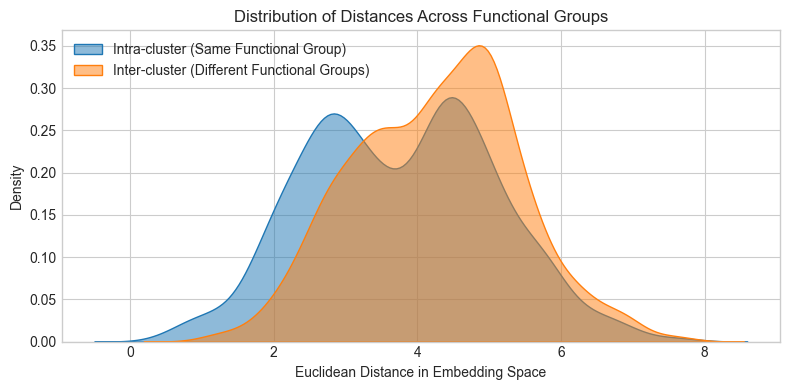

In [11]:
# ==========================================
# 3b. Pairwise Inter- and Intra-Cluster Distances
# ==========================================
from sklearn.metrics.pairwise import euclidean_distances
import seaborn as sns

# 1. Compute the full pairwise Euclidean distance matrix
dist_matrix = euclidean_distances(X_embeddings)

intra_distances = []
inter_distances = []

# 2. Extract distances based on matching/non-matching functional groups
n_samples = len(labels)
for i in range(n_samples):
    for j in range(i + 1, n_samples):  # Symmetric matrix, avoid self-comparison
        dist = dist_matrix[i, j]
        if labels[i] == labels[j]:
            intra_distances.append(dist)
        else:
            inter_distances.append(dist)

intra_distances = np.array(intra_distances)
inter_distances = np.array(inter_distances)

# 3. Print Statistical Metrics
print("\n=== Embedding Space Distance Metrics ===")
print(f"Intra-Cluster Distance (Same Group):  Mean = {intra_distances.mean():.4f} ± {intra_distances.std():.4f}")
print(f"Inter-Cluster Distance (Diff Groups): Mean = {inter_distances.mean():.4f} ± {inter_distances.std():.4f}")

# Ratio < 1.0 indicates that clusters are tighter internally than the distance between them
ratio = intra_distances.mean() / inter_distances.mean()
print(f"Intra/Inter Distance Ratio:           {ratio:.4f}")

# 4. Plot Distribution Overlap
plt.figure(figsize=(8, 4))
sns.kdeplot(intra_distances, label="Intra-cluster (Same Functional Group)", fill=True, alpha=0.5, color='#1f77b4')
sns.kdeplot(inter_distances, label="Inter-cluster (Different Functional Groups)", fill=True, alpha=0.5, color='#ff7f0e')
plt.xlabel("Euclidean Distance in Embedding Space")
plt.ylabel("Density")
plt.title("Distribution of Distances Across Functional Groups")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 3d. Conditional 1-NN Distances (Same vs Diff Group)
# ==========================================
from sklearn.metrics.pairwise import euclidean_distances

# Compute the full pairwise distance matrix
dist_matrix = euclidean_distances(X_embeddings)

same_group_1nn_distances = []
diff_group_1nn_distances = []

n_samples = len(labels)
labels_arr = np.array(labels)

for i in range(n_samples):
    current_label = labels[i]
    
    # Create masks to separate neighbors
    same_mask = (labels_arr == current_label)
    same_mask[i] = False  # False for itself so we don't pick a distance of 0.0
    
    diff_mask = (labels_arr != current_label)
    
    # Get all distances from molecule i to others
    row_distances = dist_matrix[i]
    
    # 1-NN distance within the same functional group
    if np.any(same_mask):
        same_group_1nn = np.min(row_distances[same_mask])
        same_group_1nn_distances.append(same_group_1nn)
        
    # 1-NN distance to the closest entirely different functional group
    if np.any(diff_mask):
        diff_group_1nn = np.min(row_distances[diff_mask])
        diff_group_1nn_distances.append(diff_group_1nn)

same_group_1nn_distances = np.array(same_group_1nn_distances)
diff_group_1nn_distances = np.array(diff_group_1nn_distances)

print("\n=== Conditional Local 1-NN Metrics ===")
print(f"Average 1-NN (Same Group):            Mean = {same_group_1nn_distances.mean():.4f} ± {same_group_1nn_distances.std():.4f}")
print(f"Average 1-NN (Different Group):       Mean = {diff_group_1nn_distances.mean():.4f} ± {diff_group_1nn_distances.std():.4f}")

# A local ratio significantly below 1.0 confirms clean local cluster boundaries
local_ratio = same_group_1nn_distances.mean() / diff_group_1nn_distances.mean()
print(f"Local 1-NN Ratio (Same/Diff):         {local_ratio:.4f}")
print("=========================================\n")


=== Conditional Local 1-NN Metrics ===
Average 1-NN (Same Group):            Mean = 1.7781 ± 0.8104
Average 1-NN (Different Group):       Mean = 3.4537 ± 0.7277
Local 1-NN Ratio (Same/Diff):         0.5148



# Calculate ARI for functional groups and structure class

In [ ]:
from sklearn.metrics import silhouette_score
df_acyclic = df.filter(pl.col("structure_class") == "Acyclic").sample(100)
df_aliphatic = df.filter(pl.col("structure_class") == "Aliphatic Ring").sample(100)
df_aromatic = df.filter(pl.col("structure_class") == "Aromatic").sample(100)

df_exp = pl.concat([df_acyclic, df_aliphatic, df_aromatic])
X = np.stack(df_exp["selfies_transformer"].to_numpy())
labels = df_exp["structure_class"].to_numpy()
score = silhouette_score(X, labels, metric="euclidean")

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.0792


/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


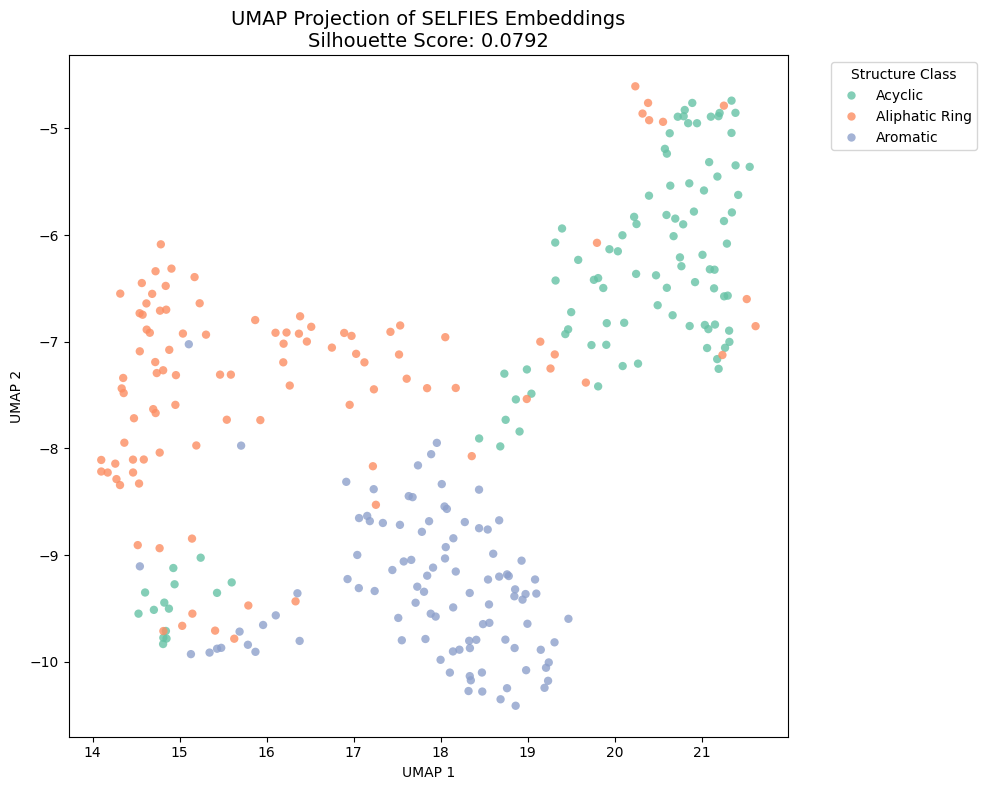

In [ ]:

# 1. Prepare data (stacking the Polars List column into a 2D numpy array)
X = np.stack(df_exp["selfies_transformer"].to_numpy())
labels = df_exp["structure_class"].to_numpy()

# 2. Initialize and run UMAP
# Using a low n_neighbors since the dataset size is small (300 samples)
reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(X)

# 3. Plotting
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=embedding_2d[:, 0],
    y=embedding_2d[:, 1],
    hue=labels,
    palette="Set2",
    alpha=0.8,
    edgecolor="none",
)

plt.title(f"UMAP Projection of SELFIES Embeddings\nSilhouette Score: {score:.4f}", fontsize=14)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Structure Class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()

plt.show()